## Environment Setup

In [1]:
# File handling and data manipulation
import zipfile
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Theme
plt.style.use('seaborn-v0_8-white')

## Data Wrangling

In [2]:
# Load data from ZIP
with zipfile.ZipFile('data/online+retail+ii.zip','r') as zip:
    with zip.open('online_retail_II.xlsx') as excel_file:
        df_dict = pd.read_excel(excel_file,sheet_name=None,engine='openpyxl')
        retail_bronze = pd.concat(df_dict.values(),axis=0,ignore_index=True)
        
# Glimpse of the datasets
retail_bronze.head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
print("=="*20)
print("Data Quality Check")
print("=="*20)

print("\nOverview:\n")
retail_bronze.info()

print("\n1. Missing Customer ID:")
print(f"   {retail_bronze['Customer ID'].isna().sum()*100/len(retail_bronze):.2f}%")

print("\n2. Missing Description:")
print(f"   {retail_bronze['Description'].isna().sum()*100/len(retail_bronze):.2f}%")

print("\n3. Duplicates Rows:")
print(f"   {retail_bronze.duplicated(
               subset=['Invoice','StockCode','Quantity',
                       'InvoiceDate','Price','Customer ID',
                       'Country']).sum()*100/len(retail_bronze):.2f}%")

print("\n4. Cancelled Orders:")
print(f"   {retail_bronze['Invoice'].astype(str).str.startswith('C').sum()*100/len(retail_bronze):.2f}%")

print("\n5. Zero or Negative Quantity:")
print(f"   {len(retail_bronze[retail_bronze['Quantity']<=0])*100/len(retail_bronze):.2f}%")
print("\n6. Zero or Negative Price:")
print(f"   {len(retail_bronze[retail_bronze['Price']<=0])*100/len(retail_bronze):.2f}%")

print("\n7. Invoice date Range:")
print(f"   {retail_bronze['InvoiceDate'].min()} - {retail_bronze['InvoiceDate'].max()}")

Data Quality Check

Overview:

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 78.8+ MB

1. Missing Customer ID:
   22.77%

2. Missing Description:
   0.41%

3. Duplicates Rows:
   3.22%

4. Cancelled Orders:
   1.83%

5. Zero or Negative Quantity:
   2.15%

6. Zero or Negative Price:
   0.58%

7. Invoice date Range:
   2009-12-01 07:45:00 - 2011-12-09 1

**Preprocessing Rationale:**

1. **Data Hygiene:** Stripped blank spaces in column names to ensure data quality.

2. **Customer ID column:** Dropped missing rows as RFM analysis requires grouping by valid ID. Handled data type by casting floats to integers to strip trailing `0` before converting to strings for use as a key column.

3. **Missing Descriptions:** Retained rows by filling with `unknown` strings. Descriptions not used for clustering in this study.

4. **Dropping Anomalies:** Removed cancelled orders (invoices starting with `C`) and entries with zero/negative quantities or prices to prevent distortion of Frequency and Monetary calculations.

5. **De-Duplication:** Dropped 3.22% duplicate rows (system errors) that would otherwise inflate results. Kept last occurrence by sorting by `InvoiceDate` before using `keep='last'`.

6. **Feature Engineering:** Calculated `TotalPrice` (Quantity × Price) for Monetary calculation.

7. **Pipeline Engineering:** Encapsulated all preprocessing steps into a reusable `cleaning` function for easy debugging and modifications.

In [4]:
def cleaning(df):

    """
    Clean retail transaction data for RFM and Cohort Analysis.
    
    Args:
      df (dataframe): A dataframe that needs cleaning.

    Returns:
      df_clean (dataframe): Cleaned dataframe.
    """

    df_clean = df.copy() # Copy for reproducibility
    
    # Data Hygiene
    df_clean.columns=df_clean.columns.str.replace(" ","")
    
    # Missing Value
    df_clean.dropna(subset = ["CustomerID"],inplace=True)
    df_clean['CustomerID']=df_clean['CustomerID'].astype(int).astype(str)
    df_clean['Description'] = df_clean['Description'].fillna('unknown')

    # Anomalies deletion
    anomalies = (df_clean['Invoice'].astype(str).str.startswith('C',na=False)) | \
                (df_clean['Quantity']<=0) | \
                (df_clean['Price']<=0)
    df_clean = df_clean[~anomalies]

    # De-Duplication
    df_clean = df_clean.sort_values(by=['InvoiceDate']).\
                        drop_duplicates(subset=['Invoice','StockCode',
                                                'Quantity','InvoiceDate',
                                                'Price','CustomerID',
                                                'Country'],keep='last')
    # Feature Engineering
    df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

    # Validation
    print(f"""\nRows dropped after cleaning: 
    {(len(df)-len(df_clean))*100/len(df):.2f}%""")
    
    # Re-index after row deletion
    return df_clean.reset_index(drop=True)
    
#Function calling
retail_silver = cleaning(retail_bronze) 


Rows dropped after cleaning: 
    26.98%


## Exploratory Data Analysis (EDA)

1. Recency (R): It measures days since last transaction for each customer. As the dataset is historical, a hypothetical snap date was calculated as one day after the last invoice date (2011-12-09). This `snap date` minus each customer's latest Invoice date was used to calculate Recency.


2. Frequency (F): It tracks the number of unique transactions for each customer. Here, `nunique()` transactions are counted because under the same invoice, a customer may have bought different items (Stockcode). 


3. Monetary Value (M): This measures how much each customer spends, which is `sum()` of Total Price (Price*Quantity).                                                                                                        

In [5]:
# Snap date
snap_date = retail_silver['InvoiceDate'].max()+pd.Timedelta(days=1)

# RFM table
rfm = retail_silver.groupby('CustomerID',as_index=False).agg(
    Recency=("InvoiceDate",lambda x: (snap_date-x.max()).days),
    Frequency = ("Invoice","nunique"),
    Monetary = ("TotalPrice","sum")
)

# Descriptive summary
print("=="*20)
print("Base RFM Metrics Summary")
print("=="*20)
print(rfm.describe().round(2))

Base RFM Metrics Summary
       Recency  Frequency   Monetary
count  5878.00    5878.00    5878.00
mean    201.33       6.29    2955.81
std     209.34      13.01   14440.29
min       1.00       1.00       2.95
25%      26.00       1.00     342.28
50%      96.00       3.00     867.74
75%     380.00       7.00    2248.30
max     739.00     398.00  580987.04


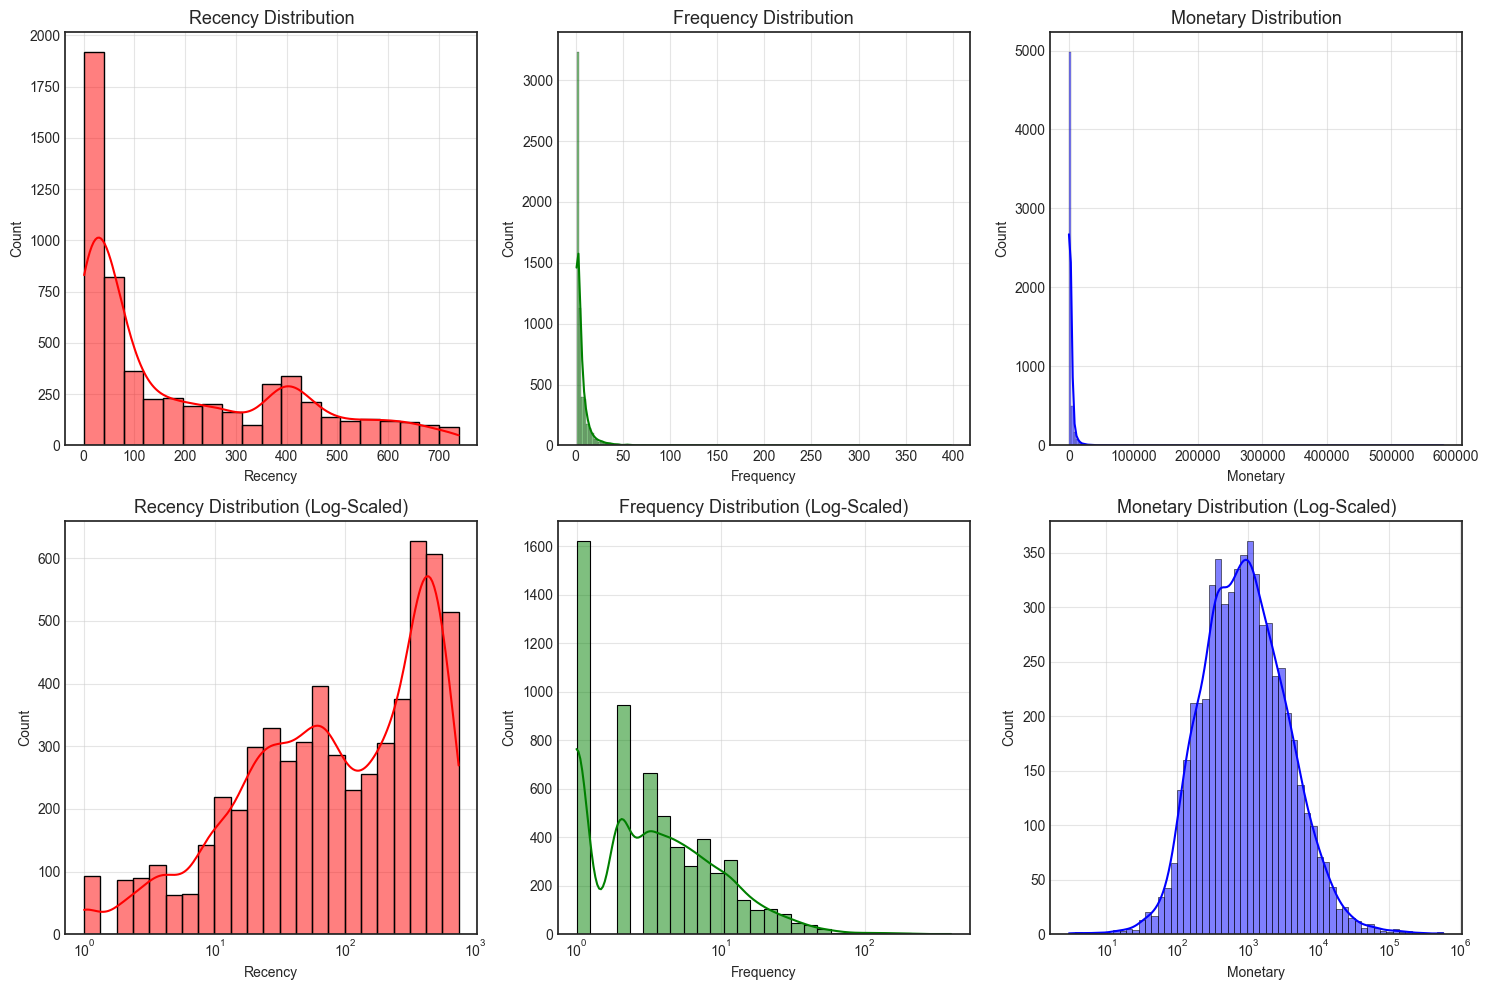

In [6]:
fig,axes = plt.subplots(2,3,figsize=(15,10))
sns.histplot(x="Recency",fill=True,data=rfm,color="red",
             kde=True,ax=axes[0,0])
sns.histplot(x="Frequency",fill=True,data=rfm,color="green",
             kde=True,ax=axes[0,1])
sns.histplot(x="Monetary",fill=True,data=rfm,color="blue",
             kde=True,ax=axes[0,2])
sns.histplot(x="Recency",fill=True,data=rfm,color="red",kde=True,
             log_scale=True,ax=axes[1,0])
sns.histplot(x="Frequency",fill=True,data=rfm,color="green",kde=True,
             log_scale=True,ax=axes[1,1])
sns.histplot(x="Monetary",fill=True,data=rfm,color="blue",
             kde=True,log_scale=True,ax=axes[1,2])
axes[0,0].set_title('Recency Distribution',fontsize=13)
axes[0,0].grid(alpha=0.5)
axes[0,1].set_title('Frequency Distribution',fontsize=13)
axes[0,1].grid(alpha=0.5)
axes[0,2].set_title('Monetary Distribution',fontsize=13)
axes[0,2].grid(alpha=0.5)
axes[1,0].set_title('Recency Distribution (Log-Scaled)',fontsize=13)
axes[1,0].grid(alpha=0.5)
axes[1,1].set_title('Frequency Distribution (Log-Scaled)',fontsize=13)
axes[1,1].grid(alpha=0.5)
axes[1,2].set_title('Monetary Distribution (Log-Scaled)',fontsize=13)
axes[1,2].grid(alpha=0.5)
plt.tight_layout()
plt.show()

### RFM Segmentation using KMeans Clustering

As observed in the plot and summary description above, RFM table shows massive positive skewness due to large value outliers, such as a £ 580,987.04 maximum spend in Monetary or 398 order count in Frequency.

To uncover true patterns of customer behavior in RFM tables, I will implement K-Means clustering, which is a popular unsupervised machine learning algorithm. K-Means groups data into clusters with naturally meaningful boundaries.

To satisfy the core mathematical assumptions of K-Means, the data needs to be symmetrical and uniformly scaled. I addressed this by applying the two steps below: 

1. **Log Transformation(`np.log()`):** Applied across raw RFM table to compress right skewness.

2. **Standardization (`StandardScaler()`):** After the log transform I will scale all R,F and M values to mean = 0 and std= 1 to ensure that larger magnitudes like monetary do not dominates distance calculations.

In [7]:
# Log transformation
X=np.log(rfm[["Recency", "Frequency", "Monetary"]])

# train-test split with 80% train set, random state for reproducibility
X_train,X_test = train_test_split(X, test_size=0.2,random_state=42)

# Standardization - fit only on train set to ensure no data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Transform only on test set
X_test_scaled = scaler.transform(X_test)

### Validation using Elbow method and Silhouette Coefficient

To determine optimal number of clusters, we will use loop to run multiple KMeans models with cluster number(k) in the range of 2 to 12. We will track two main parameters:

1. **Within-Cluster Sum of Squares (WCSS):** This measures intra-cluster distance of data points from its centroid, available by `inertia_` attribute of the fit model. While increasing k will make the WCSS lower, it can also lead to overfitting. For this trade-off, we will use elbow plot to identify optimal cluster number where inertia decreases slowly.
    
2. **Mean Silhouette Coefficient:** This measures both Inter-cluster separation and nearest-cluster distance ranging from the range -1 to 1. Values near 0 indicate overlapping clusters. This score is calculated on predicted labels to ensure validation on unseen data.

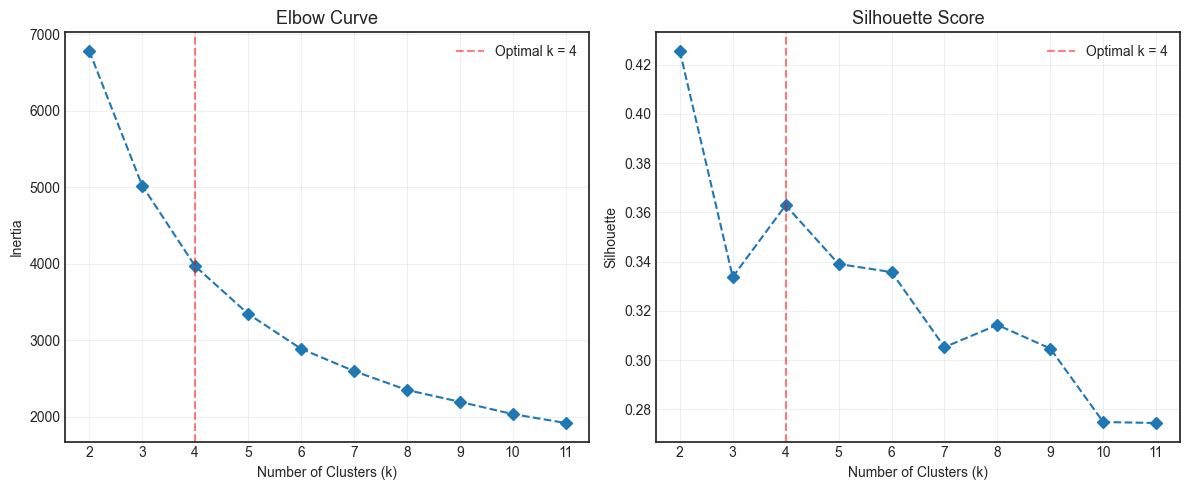

In [8]:
# Loops
inertia = []
silhouette =[]
for cluster in range(2,12): # Silhouette need at least two cluster.
    kmeans = KMeans(n_clusters = cluster,random_state = 42)
    kmeans.fit(X_train_scaled) 
    inertia.append(kmeans.inertia_)
    test_label = kmeans.predict(X_test_scaled) # Predicted lables
    silhouette.append(silhouette_score(X_test_scaled,test_label)) 
fig,axis = plt.subplots(1,2,figsize=(12,5))
axis[0].plot(range(2,12),inertia,marker='D',linestyle='--')
axis[1].plot(range(2,12),silhouette,marker='D',linestyle='--')
axis[0].set_xlabel("Number of Clusters (k)")
axis[0].set_ylabel("Inertia")
axis[0].set_title("Elbow Curve",fontsize=13)
axis[0].set_xticks(range(2,12))
axis[1].set_xticks(range(2,12))
axis[0].axvline(x=4,color='r',linestyle='--',alpha=0.5,label="Optimal k = 4")
axis[0].legend()
axis[1].axvline(x=4,color='r',linestyle='--',alpha=0.5,label="Optimal k = 4")
axis[1].legend()
axis[0].grid(alpha=0.3)
axis[1].grid(alpha=0.3)
axis[1].set_title("Silhouette Score",fontsize=13)
axis[1].set_xlabel("Number of Clusters (k)")
axis[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.show()

1. The elbow curve shows inertia dropping sharply from 7000 to 4000 between k = 2 and k = 4, then flattens significantly while the silhouette score reaches peak of 0.36 after an initial dip at k = 4. Therefore, the optimal cluster, k = 4, balances the tight cluster with inter-cluster separation.

In [9]:
# Final model fitting using the optimal k

final_kmeans = KMeans(n_clusters = 4, random_state=42)
final_kmeans.fit(X_train_scaled)
final_train_labels = final_kmeans.labels_ # Predicted labels on train dataset
final_test_labels  = final_kmeans.predict(X_test_scaled)

# assign labels back to rfm tables with right index
rfm.loc[X_train.index,'KMeans_Segment'] = final_train_labels
rfm.loc[X_test.index,'KMeans_Segment']  =  final_test_labels
rfm['KMeans_Segment'] = rfm['KMeans_Segment'].astype(int)

# Summary
print("=="*25)
print("KMeans Segment Analysis")
print("=="*25)
print(rfm.groupby("KMeans_Segment").agg(
    {"Recency"  :  "mean",
     "Frequency":  "mean",
     "Monetary" :  "mean"}
    ).sort_values('Monetary').round(2))

KMeans Segment Analysis
                Recency  Frequency  Monetary
KMeans_Segment                              
1                385.94       1.32    317.49
0                 27.78       3.09    843.63
3                233.74       5.06   1896.82
2                 26.77      18.94  10565.17


### Cluster Profiling & Business Interpretation 

While the business logic of interpreting segmentation varies across industries, a standardized mapping logic is applied here to define four segments as below:

### Absolute Performance

1. **Champions (Segment 2):** These customers have the lowest recency (27 days), buy frequently (18.94) and generate massive revenue (£10,565). Marketing should provide exclusive rewards like prime membership, early access to new product launches to maximize their retention.

2. **Promising / New Buyers (Segment 0):** Recent buyers (28 days) matching Champions in recency but have lower frequency (3.09) and total spend (£843). They should be the prime targets for marketing campaigns to turn them into repeat customers.

3. **At Risk (Segment 3):** Previously active customers (Frequency: 5.06, Monetary: £1,896) on the verge of churning - Recency (234 days) . We need to give them win-back approach like one time discounts.

4. **Churned (Segment 1):** Inactive for over a year (386 days) with Frequency=1.32 confirming predominantly one-time buyers. They should receive low-cost re-engagement efforts only, like cold emails.

### Relative Importance Segment Attributes

To evaluate how each cluster mean deviates from the global population average as below:


1. **Positive Importance (%) (Green):** Segment average is above Poulation Average.

2. **Negative Importance (%) (Red)** Segment average is below Poulation Average.

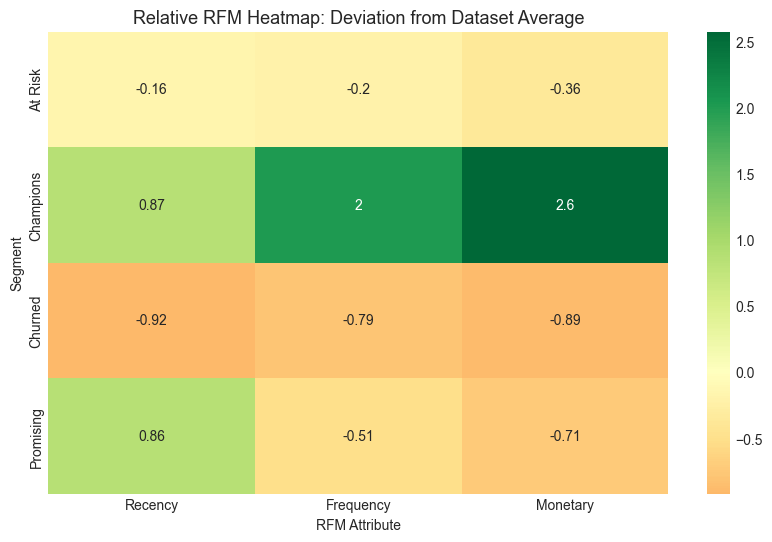

In [10]:
# Mapping the Segemnt accoring to business interpretation
rfm['KMeans_Segment_name'] = rfm['KMeans_Segment'].map(
                             {2:'Champions',
                              0:'Promising',
                              3:"At Risk",
                              1:"Churned"})
# Cluster Average
cluster_avg = rfm.groupby('KMeans_Segment_name').agg({"Recency":"mean","Frequency":"mean","Monetary":"mean"})

# Population Average
population_avg = rfm[["Recency", "Frequency", "Monetary"]].mean()

# Related Importance
relative_imp = cluster_avg/population_avg - 1

# Flipped the recency - lower better for meaningful plot
relative_imp_flipped = relative_imp.copy()
relative_imp_flipped['Recency'] = -relative_imp['Recency']

plt.figure(figsize=(10, 6))
sns.heatmap(relative_imp_flipped,annot=True,cmap='RdYlGn',center=0) # Red<Yellow<Green
plt.title("Relative RFM Heatmap: Deviation from Dataset Average",fontsize=13)
plt.xlabel('RFM Attribute')
plt.ylabel('Segment')
plt.show()

1. Champions are exceptional, 260% above the population monetary average). All other segments show red across frequency and/or monetary, indicating significant opportunity marketing campaigns.

### Cohort Analysis: Time Based

While RFM gives a static customer snapshot, Cohort Analysis adds the temporal dimension of behavior over time.
    
**Feature Engineering:**
    
| Feature | Description |
|---------|-------------|
| `CohortMonth` | Customer's first purchase month |
| `InvoiceMonth` | Transaction month start |
| `CohortIndex` | Months elapsed since first purchase (0,1,2...) |
| `Cohort_count` | Active customers per cohort (wider format) |
| `Cohort_sizes` | Total unique customers acquired in that Cohort |
| `Retention` | Active % = Count / Cohort_sizes |

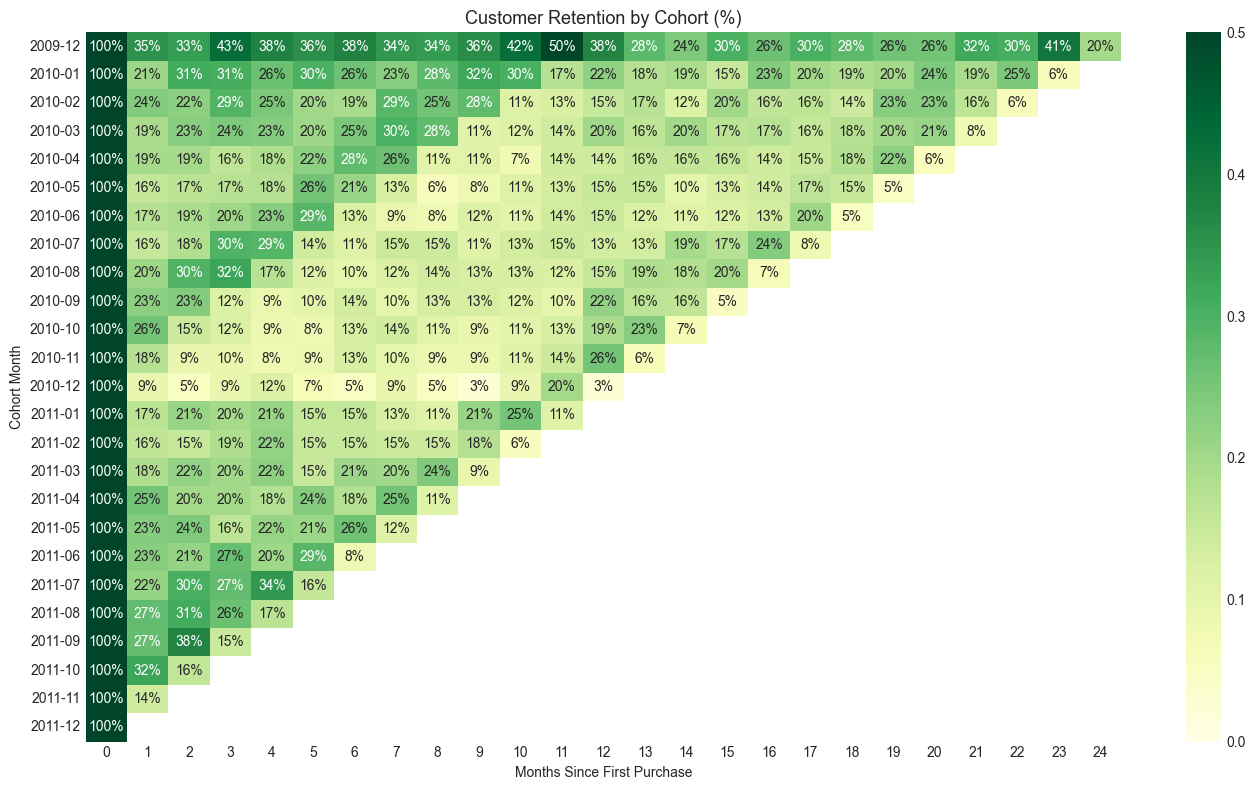

In [11]:
# CohortMonth
retail_silver['CohortMonth']  =  retail_silver.groupby('CustomerID')['InvoiceDate'].transform('min').dt.to_period('M')

# InvoiceMonth
retail_silver['InvoiceMonth'] =  retail_silver['InvoiceDate'].dt.to_period('M')

# CohortIndex
retail_silver['CohortIndex']  =  (retail_silver['InvoiceMonth'].dt.year - retail_silver['CohortMonth'].dt.year)*12 +\
                                  (retail_silver['InvoiceMonth'].dt.month - retail_silver['CohortMonth'].dt.month)
# Cohort Matrix in wider format
Cohort_count = retail_silver.pivot_table(values = 'CustomerID',index= "CohortMonth",columns= 'CohortIndex',aggfunc='nunique')

# Cohort sizes
Cohort_sizes = Cohort_count.iloc[:,0]

# Retention Percentage
Retention = Cohort_count.divide(Cohort_sizes,axis=0)

# Plot
plt.figure(figsize=(14, 8))
sns.heatmap(Retention,annot=True,
            fmt='.0%', # annote as % value
            cmap='YlGn',
            vmin=0, # Minimum color floor
            vmax=0.5 # Maximam color ceiling
           ) 
plt.title('Customer Retention by Cohort (%)', fontsize=13)
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')  
plt.tight_layout()
plt.show()

### Retention Heatmap Findings

| Finding                               | Insight                                                | Action                                           |
|--------------------------------------|--------------------------------------------------------|--------------------------------------------------|
| **78.83% Month 1 Churn**             | One-time buyers dominate (aligns with RFM Churned Segment) | Low-cost re-engagement efforts               |
| **Dec 2009 = Strongest Month 1 Retention** | Loyal customers from early days                    | Exclusive rewards like Champions Segment in RFM |
| **19.69% survive to Month 24**       | Loyal recurring customer base (aligns with RFM Champions) | Loyalty programs & exclusive benefits        |
| **Dec 2010 = Weakest Month 1 Retention** | Seasonal buyer (aligns with RFM At Risk Segment)   | Post-Christmas win-back approach               |

In [12]:
print("=="*30)
print("Heatmap: Validation")
print("=="*30)
print(f"\n1. Total Unique Customers across All Cohorts: {Cohort_sizes.sum()}")
print(f"\n2. Average Month 1 Churn rate: {1-Retention.iloc[:,1].mean():.2%}")
print(f"\n4. Average Month 24 Retetion rate: {Retention.iloc[:,24].mean():.2%}")
print(f"\n5. Strongest Cohort Month: {Retention.iloc[:,1].idxmax()}")
print(f"\n6. Weakest Cohort Month: {Retention.iloc[:,1].idxmin()}")

Heatmap: Validation

1. Total Unique Customers across All Cohorts: 5878.0

2. Average Month 1 Churn rate: 78.83%

4. Average Month 24 Retetion rate: 19.69%

5. Strongest Cohort Month: 2009-12

6. Weakest Cohort Month: 2010-12
